In [1]:
import pandas as pd

# List of file paths
file_paths = [
    '../grain_df_16_100.csv',
    '../grain_df_20_10_1.3.csv',
    '../grain_df_20_10_1.6.csv',
    '../grain_df_20_100.csv',
    '../grain_df_24_1.3_10.csv',
    '../grain_df_24_1.3_100.csv',
    '../grain_df_24_10.csv',
    '../grain_df_24_1.3_10.csv',
]

# Read and concatenate all CSV files
df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

# Now `df` contains data from all 5 files


In [2]:
df

,timestamp,grain_id,perimeter,avg_area_of_neighbors,number_of_neighbors,vulnerable,area,circularity,area_perimeter_ratio,is_vulnerable
0,0,10,56,376.400000,5,0.0,273,1.093947,4.875000,0
1,0,27,97,329.142857,7,0.0,364,0.486147,3.752577,0
2,0,38,27,305.000000,5,0.0,82,1.413501,3.037037,0
3,0,45,90,304.000000,8,0.0,715,1.109254,7.944444,0
4,0,51,75,444.285714,7,0.0,538,1.201904,7.173333,0
...,...,...,...,...,...,...,...,...,...,...
131377,20000,4596,329,3847.142857,7,0.0,7498,0.870489,22.790274,0
131378,20000,4773,220,4297.833333,6,0.0,4452,1.155898,20.236364,0
131379,20000,4792,144,5442.800000,5,0.0,2012,1.219306,13.972222,0
131380,20000,4809,418,4777.000000,7,0.0,9523,0.684906,22.782297,0


In [3]:
df.drop(columns=['vulnerable'], inplace=True)

In [4]:
df

,timestamp,grain_id,perimeter,avg_area_of_neighbors,number_of_neighbors,area,circularity,area_perimeter_ratio,is_vulnerable
0,0,10,56,376.400000,5,273,1.093947,4.875000,0
1,0,27,97,329.142857,7,364,0.486147,3.752577,0
2,0,38,27,305.000000,5,82,1.413501,3.037037,0
3,0,45,90,304.000000,8,715,1.109254,7.944444,0
4,0,51,75,444.285714,7,538,1.201904,7.173333,0
...,...,...,...,...,...,...,...,...,...
131377,20000,4596,329,3847.142857,7,7498,0.870489,22.790274,0
131378,20000,4773,220,4297.833333,6,4452,1.155898,20.236364,0
131379,20000,4792,144,5442.800000,5,2012,1.219306,13.972222,0
131380,20000,4809,418,4777.000000,7,9523,0.684906,22.782297,0


In [5]:
features = [
    "perimeter", "avg_area_of_neighbors", "number_of_neighbors",
    "area", "circularity", "area_perimeter_ratio"
]
target = "is_vulnerable"

In [6]:
X = df[features]
y = df[target]

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
data_pred=pd.read_csv('../grain_df_24_10_1.6.csv')

In [11]:
df_pred=pd.DataFrame(data_pred)

In [12]:
df_pred.drop(columns=['vulnerable'],inplace=True)

In [13]:
df_pred_test=df_pred[features]

In [14]:
df_pred

,timestamp,grain_id,perimeter,avg_area_of_neighbors,number_of_neighbors,area,circularity,area_perimeter_ratio,is_vulnerable
0,0,10,56,376.400000,5,273,1.093947,4.875000,0
1,0,27,97,329.142857,7,364,0.486147,3.752577,0
2,0,38,27,305.000000,5,82,1.413501,3.037037,0
3,0,45,90,304.000000,8,715,1.109254,7.944444,0
4,0,51,75,444.285714,7,538,1.201904,7.173333,0
...,...,...,...,...,...,...,...,...,...
22044,20000,4773,201,5824.800000,5,3734,1.161427,18.577114,1
22045,20000,4792,151,5100.600000,5,2217,1.221861,14.682119,1
22046,20000,4809,409,3265.777778,9,9135,0.686233,22.334963,1
22047,20000,4843,82,5139.333333,3,619,1.156839,7.548780,1


              precision    recall  f1-score   support

           0       0.97      0.91      0.94     20835
           1       0.24      0.47      0.32      1214

    accuracy                           0.89     22049
   macro avg       0.60      0.69      0.63     22049
weighted avg       0.93      0.89      0.91     22049



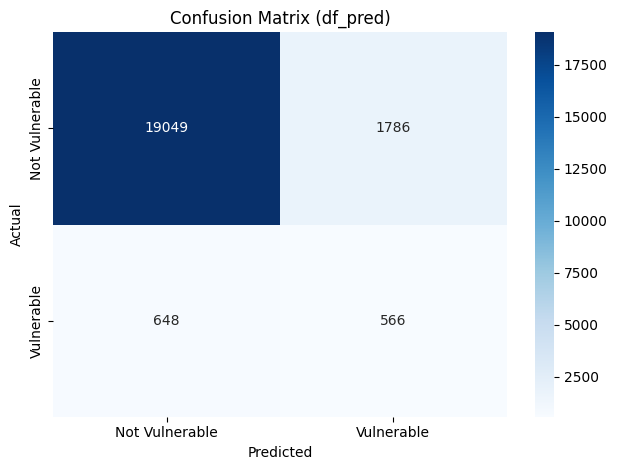

In [15]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize and train the Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 2. Predict
predicted_vulnerability = clf.predict(df_pred_test)

# 3. Add predictions to the original df for comparison
df_pred["predicted_vulnerable"] = predicted_vulnerability

# 4. Evaluate if true labels exist
if "is_vulnerable" in df_pred.columns:
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    print(classification_report(df_pred["is_vulnerable"], df_pred["predicted_vulnerable"]))

    conf_matrix = confusion_matrix(df_pred["is_vulnerable"], df_pred["predicted_vulnerable"])
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Vulnerable", "Vulnerable"],
                yticklabels=["Not Vulnerable", "Vulnerable"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix (df_pred)")
    plt.tight_layout()
    plt.show()


In [16]:
import pickle
with open("vulnerability_model.pkl", "wb") as f:
    pickle.dump(clf, f)

print("Model saved to vulnerability_model.pkl")


Model saved to vulnerability_model.pkl


              precision    recall  f1-score   support

           0       0.98      1.00      0.99     23572
           1       0.95      0.80      0.87      2705

    accuracy                           0.98     26277
   macro avg       0.97      0.90      0.93     26277
weighted avg       0.97      0.98      0.97     26277



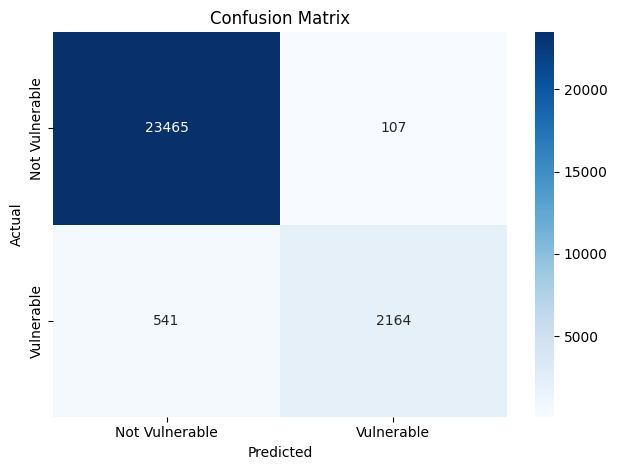

In [17]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 6. Predict & evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# 7. Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Vulnerable", "Vulnerable"], yticklabels=["Not Vulnerable", "Vulnerable"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [18]:
data1=pd.read_csv('../grain_df_24_10.csv')

In [19]:
df1=pd.DataFrame(data1)

In [20]:
df1.drop(columns=['vulnerable'],inplace=True)

In [21]:
df = pd.concat([df, df1], ignore_index=True)

In [22]:
# df.drop(columns=['vulnerable'],inplace=True)

In [23]:
df

,timestamp,grain_id,perimeter,avg_area_of_neighbors,number_of_neighbors,area,circularity,area_perimeter_ratio,is_vulnerable
0,0,10,56,376.400000,5,273,1.093947,4.875000,0
1,0,27,97,329.142857,7,364,0.486147,3.752577,0
2,0,38,27,305.000000,5,82,1.413501,3.037037,0
3,0,45,90,304.000000,8,715,1.109254,7.944444,0
4,0,51,75,444.285714,7,538,1.201904,7.173333,0
...,...,...,...,...,...,...,...,...,...
144248,302000,4596,253,6298.400000,5,5232,1.027156,20.679842,0
144249,302000,4773,162,8080.400000,5,2655,1.271289,16.388889,0
144250,302000,4809,670,5433.666667,9,15177,0.424860,22.652239,0
144251,302000,4843,209,7400.600000,5,3579,1.029625,17.124402,0
